# Modelos lineales de clasificación multiclase

In [1]:
import pandas as pd

df = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data-original",
    sep=r'\s+',
    header=None,
    names=['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'car_name']
    )

df = df.drop('car_name', axis=1)
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8.0,307.0,130.0,3504.0,12.0,70.0,1.0
1,15.0,8.0,350.0,165.0,3693.0,11.5,70.0,1.0
2,18.0,8.0,318.0,150.0,3436.0,11.0,70.0,1.0
3,16.0,8.0,304.0,150.0,3433.0,12.0,70.0,1.0
4,17.0,8.0,302.0,140.0,3449.0,10.5,70.0,1.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     406 non-null    float64
 2   displacement  406 non-null    float64
 3   horsepower    400 non-null    float64
 4   weight        406 non-null    float64
 5   acceleration  406 non-null    float64
 6   model_year    406 non-null    float64
 7   origin        406 non-null    float64
dtypes: float64(8)
memory usage: 25.5 KB


Vamos a ver si en las variables predictoras hay diferencias significativas entre países de origen.

In [3]:
from sklearn.model_selection import train_test_split
X = df.drop('origin', axis=1)
y = df['origin']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=72, train_size=0.7)
print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (284, 7)
Tamaño del conjunto de prueba es: (122, 7)


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

num_vars = X_train.select_dtypes(include=['number']).columns.drop(['model_year', 'cylinders'])
num_processor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
     ('scaler', StandardScaler())
     ])

cyl_processor = OrdinalEncoder(categories=[['3', '4', '5', '6', '8']])
year_processor = OrdinalEncoder(categories=[['70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82']])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_processor, num_vars),
        ('cyl', cyl_processor, ['cylinders']),
        ('year', year_processor, ['model_year']),
        ])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 Index(['mpg', 'displacement', 'horsepower', 'weight', 'acceleration'], dtype='object')),
                                ('cyl',
                                 OrdinalEncoder(categories=[['3', '4', '5', '6',
                                                             '8']]),
                                 ['cylinders']),
                                ('year',
                                 OrdinalEncoder(categories=[['70', '71', '72',
                                                             '73', '74', '75',
                                                             '76', '77', '78',
                                                             '79', '80', '81',
                                                             '82']]),
                                 ['model_year'])])

In [5]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
     ('clf', LogisticRegression(
         solver='saga',
         max_iter=10000,
         penalty='elasticnet',
         random_state=72
         ))
     ])

grid = {
    'clf__l1_ratio': uniform(0, 1),
    'clf__C':loguniform(1e-4, 1e4)
    }

tuner = RandomizedSearchCV(
    estimator=model,
    param_distributions=grid,
    scoring='f1_macro',
    n_iter=50,
    random_state=72
    )

tuner.fit(X_train, y_train)

print(f'Crossvalidation score: {tuner.best_score_:.3f}')
print(f'Mejores hiperparámetos: {tuner.best_params_}')
print(f'Train score: {tuner.score(X_train, y_train):.3f}')
print(f'Test score: {tuner.score(X_test, y_test):.3f}')

Crossvalidation score: 0.699
Mejores hiperparámetos: {'clf__C': np.float64(19.242922036853354), 'clf__l1_ratio': np.float64(0.318644250834646)}
Train score: 0.741
Test score: 0.590


En este caso, la matriz de confusión es $3*3$:

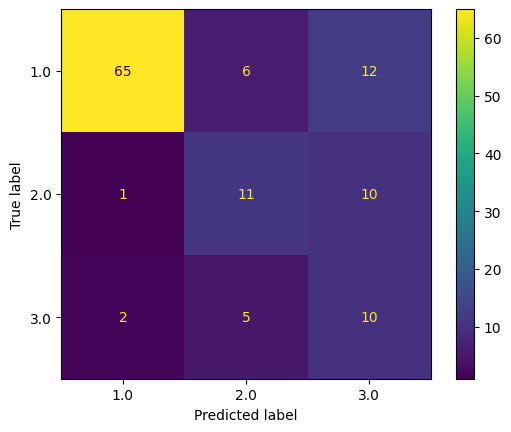

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(tuner.best_estimator_, X_test, y_test);

Y el reporte de clasificación tiene 3 filas:

In [7]:
from sklearn.metrics import classification_report

print(classification_report(y_test, tuner.predict(X_test)))

              precision    recall  f1-score   support

         1.0       0.96      0.78      0.86        83
         2.0       0.50      0.50      0.50        22
         3.0       0.31      0.59      0.41        17

    accuracy                           0.70       122
   macro avg       0.59      0.62      0.59       122
weighted avg       0.78      0.70      0.73       122



El modelo optimiza los pesos para cada clase, utilizando el método [**Softmax**](https://en.wikipedia.org/wiki/Softmax_function). Por esta razón, en este caso, cada característica tendrá 3 pesos asociados.

In [8]:
pesos = pd.DataFrame(
    data=tuner.best_estimator_.named_steps['clf'].coef_,
    columns=tuner.best_estimator_.named_steps['preprocessor'].get_feature_names_out(),
    index=['pesos_1', 'pesos_2', 'pesos_3']
    )

pesos['intercept'] = tuner.best_estimator_.named_steps['clf'].intercept_
pesos.T.round(3)

,pesos_1,pesos_2,pesos_3
num__mpg,-0.294,0.327,0.000
num__displacement,10.012,-5.896,-3.918
num__horsepower,0.021,-1.190,1.259
num__weight,-3.154,3.875,-0.528
num__acceleration,0.215,-0.221,0.000
cyl__cylinders,-1.373,0.456,0.750
year__model_year,0.069,-0.248,0.000
intercept,5.855,-1.988,-3.867


Con el método `predict_proba()`se pueden ver los probabilidades que calculó el modelo para cada clase, en cada predicción:

In [9]:
probs = pd.DataFrame(
    data=tuner.best_estimator_.predict_proba(X_test).round(4),
    columns=['prob_1', 'prob_2', 'prob_3'],
    index=X_test.index
    )

probs

,prob_1,prob_2,prob_3
238,1.0000,0.0000,0.0000
80,0.9999,0.0001,0.0000
192,0.0801,0.4018,0.5180
262,0.7318,0.1645,0.1036
52,1.0000,0.0000,0.0000
...,...,...,...
107,1.0000,0.0000,0.0000
273,0.1356,0.3617,0.5027
313,0.7641,0.0129,0.2231
359,0.1132,0.4334,0.4534


Puede intentarse aplicar balanceo de clases.

In [10]:
grid = {
    'clf__l1_ratio': uniform(0, 1),
    'clf__C':loguniform(1e-4, 1e4),
    'clf__class_weight':['balanced', None]
    }

tuner = RandomizedSearchCV(
    estimator=model,
    param_distributions=grid,
    scoring='f1_macro',
    n_iter=50,
    random_state=72
    )

tuner.fit(X_train, y_train)

print(f'Crossvalidation score: {tuner.best_score_:.3f}')
print(f'Mejores hiperparámetos: {tuner.best_params_}')
print(f'Train score: {tuner.score(X_train, y_train):.3f}')
print(f'Test score: {tuner.score(X_test, y_test):.3f}')

Crossvalidation score: 0.701
Mejores hiperparámetos: {'clf__C': np.float64(901.3862687098543), 'clf__class_weight': 'balanced', 'clf__l1_ratio': np.float64(0.500678872676934)}
Train score: 0.728
Test score: 0.584


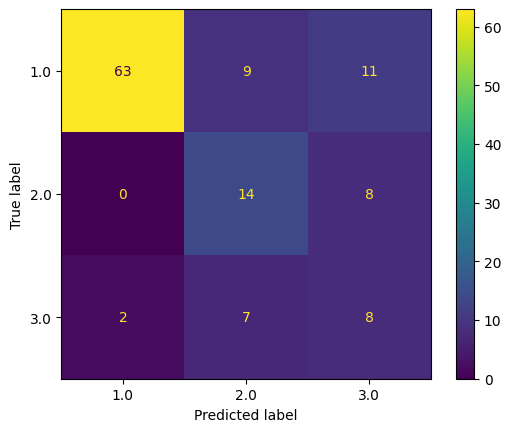

In [11]:
ConfusionMatrixDisplay.from_estimator(tuner.best_estimator_, X_test, y_test);

In [12]:
print(classification_report(y_test, tuner.predict(X_test)))

              precision    recall  f1-score   support

         1.0       0.97      0.76      0.85        83
         2.0       0.47      0.64      0.54        22
         3.0       0.30      0.47      0.36        17

    accuracy                           0.70       122
   macro avg       0.58      0.62      0.58       122
weighted avg       0.78      0.70      0.73       122



In [13]:
probs = pd.DataFrame(
    data=tuner.best_estimator_.predict_proba(X_test).round(4),
    columns=['prob_1', 'prob_2', 'prob_3'],
    index=X_test.index
    )

probs

,prob_1,prob_2,prob_3
238,1.0000,0.0000,0.0000
80,1.0000,0.0000,0.0000
192,0.0179,0.4741,0.5080
262,0.5511,0.2938,0.1551
52,1.0000,0.0000,0.0000
...,...,...,...
107,1.0000,0.0000,0.0000
273,0.0386,0.4557,0.5057
313,0.6978,0.0177,0.2845
359,0.0296,0.5207,0.4497


Por defecto, sintonizadores como GridSearchCV o RandomizedSearchCV solo funcionan con métricas promediadas:

In [14]:
from sklearn.metrics import recall_score, make_scorer, precision_score

tuner = RandomizedSearchCV(
    estimator=model,
    param_distributions=grid,
    scoring='recall_macro',
    n_iter=50,
    random_state=72
    )

tuner.fit(X_train, y_train)

print(f'Crossvalidation score: {tuner.best_score_:.3f}')
print(f'Mejores hiperparámetos: {tuner.best_params_}')
print(f'Train score: {tuner.score(X_train, y_train):.3f}')
print(f'Test score: {tuner.score(X_test, y_test):.3f}')

Crossvalidation score: 0.718
Mejores hiperparámetos: {'clf__C': np.float64(901.3862687098543), 'clf__class_weight': 'balanced', 'clf__l1_ratio': np.float64(0.500678872676934)}
Train score: 0.742
Test score: 0.622


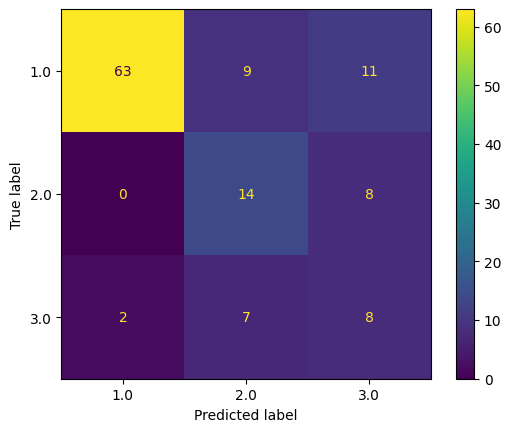

In [15]:
ConfusionMatrixDisplay.from_estimator(tuner.best_estimator_, X_test, y_test);

In [16]:
print(classification_report(y_test, tuner.predict(X_test)))

              precision    recall  f1-score   support

         1.0       0.97      0.76      0.85        83
         2.0       0.47      0.64      0.54        22
         3.0       0.30      0.47      0.36        17

    accuracy                           0.70       122
   macro avg       0.58      0.62      0.58       122
weighted avg       0.78      0.70      0.73       122



In [17]:
probs = pd.DataFrame(
    data=tuner.best_estimator_.predict_proba(X_test).round(4),
    columns=['prob_1', 'prob_2', 'prob_3'],
    index=X_test.index
    )

probs

,prob_1,prob_2,prob_3
238,1.0000,0.0000,0.0000
80,1.0000,0.0000,0.0000
192,0.0179,0.4741,0.5080
262,0.5511,0.2938,0.1551
52,1.0000,0.0000,0.0000
...,...,...,...
107,1.0000,0.0000,0.0000
273,0.0386,0.4557,0.5057
313,0.6978,0.0177,0.2845
359,0.0296,0.5207,0.4497
